# Inflation Forecasting with FRED-MD Data

Forecasts **1-month-ahead annualized PCE inflation (PCEPI)** using FRED-MD monthly vintages.

## Pipeline
- **Training data:** most recent vintage CSV from `data/vintages/`
- **Test data:** Feb 2026 current file at `data/2026-02-md.csv`
- **Target:** `PCEPI` growth (log 1st diff × 100), shifted 1 month ahead
- **Primary model:** ElasticNet with TimeSeriesSplit CV

## Models compared
ElasticNet | Ridge | Lasso | Random Forest | Gradient Boosting

## Cell 1 — Setup & Imports

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Add src to path whether running from notebooks/ or repo root
for p in ['../src', 'src']:
    if os.path.exists(p) and p not in sys.path:
        sys.path.insert(0, p)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from dotenv import load_dotenv
load_dotenv(dotenv_path='../.env')
FRED_API_KEY = os.environ.get('FRED_API_KEY')
print(f"FRED_API_KEY loaded: {FRED_API_KEY is not None}")

from data_loader import (
    load_fred_md_file, get_latest_vintage, build_dataset,
    build_dataset_with_fred_target,
)
from models import InflationForecaster, compare_models

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Resolve data paths (works from notebooks/ or repo root)
DATA_ROOT = '../data' if os.path.exists('../data') else 'data'
VINTAGE_DIR = DATA_ROOT          # vintage files are directly in data/, not a subdirectory

print("Data root :", os.path.abspath(DATA_ROOT))
print("Vintage dir exists:", os.path.isdir(VINTAGE_DIR))

FRED_API_KEY loaded: True
Data root : /home/lukeholmes/2025-2026/ML/final-project/Macro-Econ-ML/notebooks/data
Vintage dir exists: True


## Cell 2 — Data Loading

In [2]:
# Find the most recent vintage file in data/
train_file = get_latest_vintage(VINTAGE_DIR)

# Build dataset with FRED API target: features at t -> PCEPI growth at t+1
X_train, y_train, X_val, y_val, X_test, y_test, feature_names = build_dataset_with_fred_target(
    vintage_filepath=train_file,
    fred_api_key=FRED_API_KEY,
    target_series='PCEPI',
    horizon=1,
    train_frac=0.70,
    val_frac=0.15,
)

print(f"\nTrain  samples : {len(X_train)}  features: {len(feature_names)}")
print(f"  Date range   : {X_train.index.min().date()} -> {X_train.index.max().date()}")
print(f"\nVal    samples : {len(X_val)}")
print(f"  Date range   : {X_val.index.min().date()} -> {X_val.index.max().date()}")
print(f"\nTest   samples : {len(X_test)}")
if len(X_test):
    print(f"  Date range   : {X_test.index.min().date()} -> {X_test.index.max().date()}")

print(f"\nTarget (PCEPI 1-month-ahead growth) stats (train):")
print(y_train.describe().round(3))

Using latest vintage: 2026-02-MD.csv
Loading features from: data/2026-02-MD.csv
Fetching PCEPI from FRED API…

Dataset summary (PCEPI target, 1-month-ahead):
  Train :  562 obs  1959-01-31 → 2005-10-31
  Val   :  120 obs  2005-11-30 → 2015-10-31
  Test  :  121 obs  2015-11-30 → 2025-11-30
  Features: 126

Train  samples : 562  features: 126
  Date range   : 1959-01-31 -> 2005-10-31

Val    samples : 120
  Date range   : 2005-11-30 -> 2015-10-31

Test   samples : 121
  Date range   : 2015-11-30 -> 2025-11-30

Target (PCEPI 1-month-ahead growth) stats (train):
count    562.000
mean       0.303
std        0.244
min       -0.341
25%        0.138
50%        0.260
75%        0.428
max        1.221
Name: PCEPI_target, dtype: float64


## Cell 3 — Transformations & Target Construction

Transformation codes for key series:
  Series  TCode         Transform
   PCEPI    6.0 Log 1st diff x100
CPIAUCSL    6.0 Log 1st diff x100
  UNRATE    2.0          1st diff
FEDFUNDS    2.0          1st diff
   TB3MS    2.0          1st diff
    GS10    2.0          1st diff
  INDPRO    5.0 Log 1st diff x100
   HOUST    4.0               Log


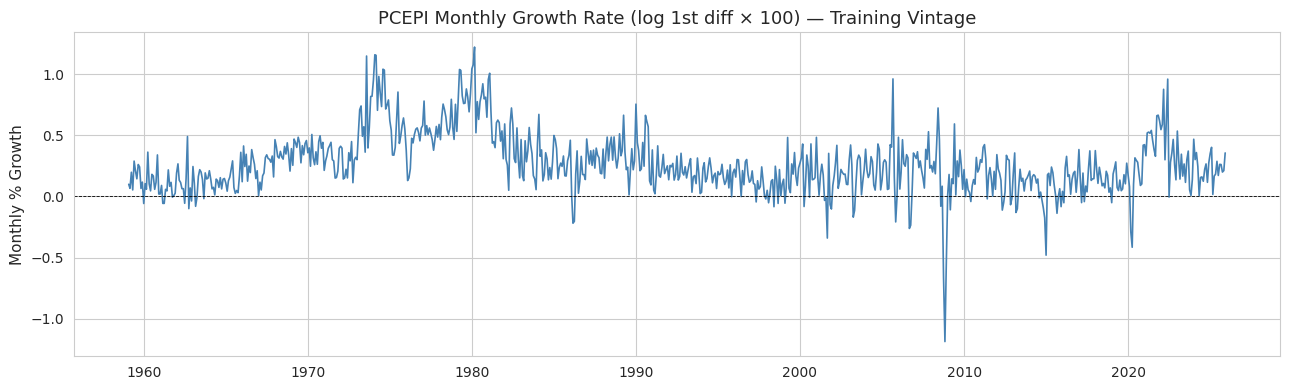


PCEPI annualized growth stats:
  Pre-pandemic mean (2015-2019): 1.43%
  Pandemic peak (2021-2022):     11.51% max

Lag structure: y[t] = PCEPI growth at t+1 (1-month-ahead forecast)
  Features cover: 1959-01-31 to 2005-10-31
  y[t] covers   : 1959-01-31 to 2005-10-31


In [3]:
from data_loader import load_fred_md_file

# Load raw (transformed) train file to inspect PCEPI growth series
df_train_full, tcodes = load_fred_md_file(train_file)

# Show tcodes for key series
key_series = ['PCEPI', 'CPIAUCSL', 'UNRATE', 'FEDFUNDS', 'TB3MS', 'GS10', 'INDPRO', 'HOUST']
tcode_info = {s: tcodes.get(s, 'N/A') for s in key_series if s in tcodes or s in df_train_full.columns}
tcode_df = pd.DataFrame(list(tcode_info.items()), columns=['Series', 'TCode'])
tcode_descriptions = {
    1: 'No transform', 2: '1st diff', 3: '2nd diff',
    4: 'Log', 5: 'Log 1st diff x100', 6: 'Log 1st diff x100', 7: 'Delta pct chg x100'
}
tcode_df['Transform'] = tcode_df['TCode'].map(lambda x: tcode_descriptions.get(int(x), str(x)) if x != 'N/A' else 'N/A')
print("Transformation codes for key series:")
print(tcode_df.to_string(index=False))

# Plot PCEPI monthly growth
pcepi_growth = df_train_full['PCEPI'].dropna() if 'PCEPI' in df_train_full.columns else None

if pcepi_growth is not None:
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(pcepi_growth.index, pcepi_growth.values, linewidth=1.2, color='steelblue')
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_title('PCEPI Monthly Growth Rate (log 1st diff × 100) — Training Vintage')
    ax.set_ylabel('Monthly % Growth')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    fig.tight_layout()
    plt.show()

    # Show that annualized values look like real inflation history
    annualized = pcepi_growth * 12
    print(f"\nPCEPI annualized growth stats:")
    print(f"  Pre-pandemic mean (2015-2019): {annualized['2015':'2019'].mean():.2f}%")
    print(f"  Pandemic peak (2021-2022):     {annualized['2021':'2022'].max():.2f}% max")

print("\nLag structure: y[t] = PCEPI growth at t+1 (1-month-ahead forecast)")
print(f"  Features cover: {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"  y[t] covers   : {y_train.index.min().date()} to {y_train.index.max().date()}")

## Cell 4 — Exploratory Data Analysis

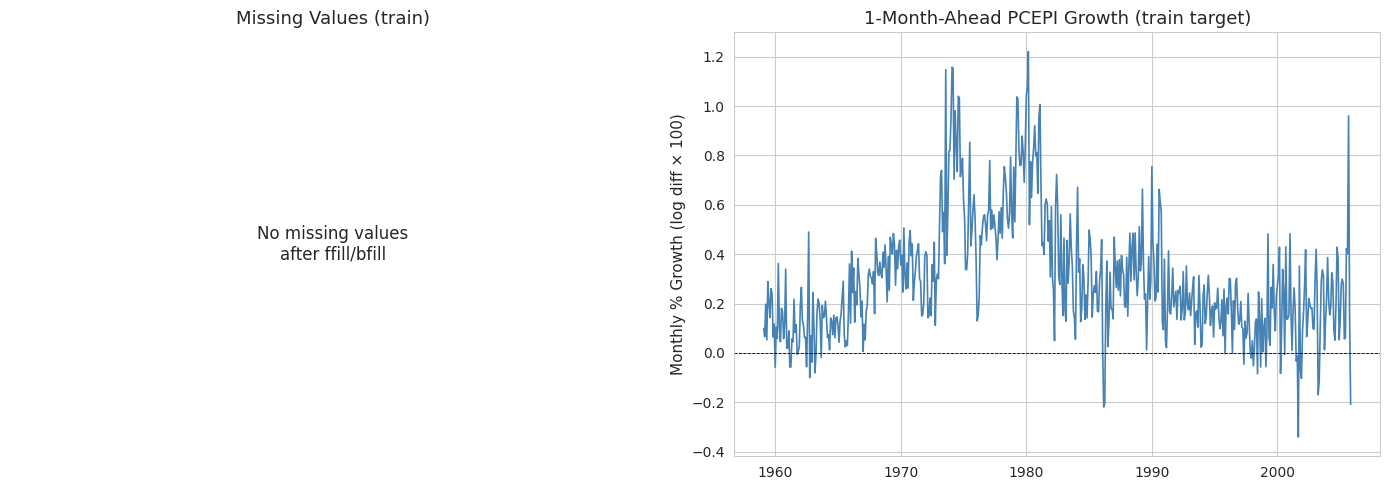

Top 15 features correlated with 1-month-ahead PCEPI growth:
PCEPI              0.725
CPIAUCSL           0.690
CUSR0000SA0L5      0.678
CPIULFSL           0.648
DSERRG3M086SBEA    0.628
CUSR0000SA0L2      0.625
CUSR0000SAC        0.595
WPSFD49207         0.583
CUSR0000SAD        0.554
CUSR0000SAS        0.550
DNDGRG3M086SBEA    0.538
TB3SMFFM           0.529
WPSFD49502         0.526
WPSID61            0.511
DDURRG3M086SBEA    0.510


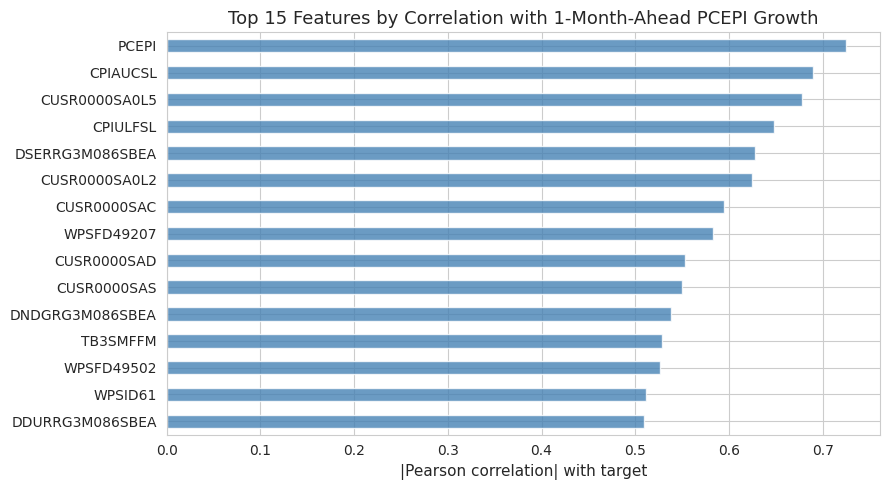

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Missing values heatmap (sample of features) ---
n_show = min(40, len(feature_names))
missing_pct = (X_train[feature_names[:n_show]].isna().sum() / len(X_train) * 100).sort_values(ascending=False)
top_missing = missing_pct[missing_pct > 0].head(20)
if len(top_missing):
    top_missing.plot(kind='barh', ax=axes[0], color='coral')
    axes[0].set_xlabel('% Missing')
    axes[0].set_title('Features with Missing Values (train)')
else:
    axes[0].text(0.5, 0.5, 'No missing values\nafter ffill/bfill',
                 ha='center', va='center', fontsize=12)
    axes[0].set_title('Missing Values (train)')
    axes[0].axis('off')

# --- PCEPI 1-month-ahead target over time ---
axes[1].plot(y_train.index, y_train.values, linewidth=1.2, color='steelblue')
axes[1].axhline(0, color='black', linewidth=0.6, linestyle='--')
axes[1].set_title('1-Month-Ahead PCEPI Growth (train target)')
axes[1].set_ylabel('Monthly % Growth (log diff × 100)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.tight_layout()
plt.show()

# --- Top 15 features correlated with target ---
corr = X_train.corrwith(y_train).abs().dropna().sort_values(ascending=False)
print("Top 15 features correlated with 1-month-ahead PCEPI growth:")
print(corr.head(15).round(3).to_string())

top_corr = corr.head(15)
if len(top_corr) > 0:
    fig2, ax2 = plt.subplots(figsize=(9, 5))
    top_corr.plot(kind='barh', ax=ax2, color='steelblue', alpha=0.8)
    ax2.set_xlabel('|Pearson correlation| with target')
    ax2.set_title('Top 15 Features by Correlation with 1-Month-Ahead PCEPI Growth')
    ax2.invert_yaxis()
    fig2.tight_layout()
    plt.show()
else:
    print("No valid correlations computed (all NaN).")

## Cell 5 — Train ElasticNet (Primary Model)

Tuning hyperparameters for elasticnet...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best parameters: {'alpha': 0.01, 'l1_ratio': 0.3}
Best CV score (RMSE): 0.1988
TimeSeriesSplit CV results (ElasticNet, best params):
 fold  n_val     rmse      mae        r2
    1     93 0.335534 0.248789 -0.918974
    2     93 0.206977 0.169186  0.066937
    3     93 0.183576 0.151138 -0.304301
    4     93 0.122968 0.099763  0.057421
    5     93 0.179723 0.134543  0.010361

Mean CV RMSE: 0.2058  |  Mean R²: -0.2177
Best hyperparams: {'alpha': 0.01, 'l1_ratio': 0.3}


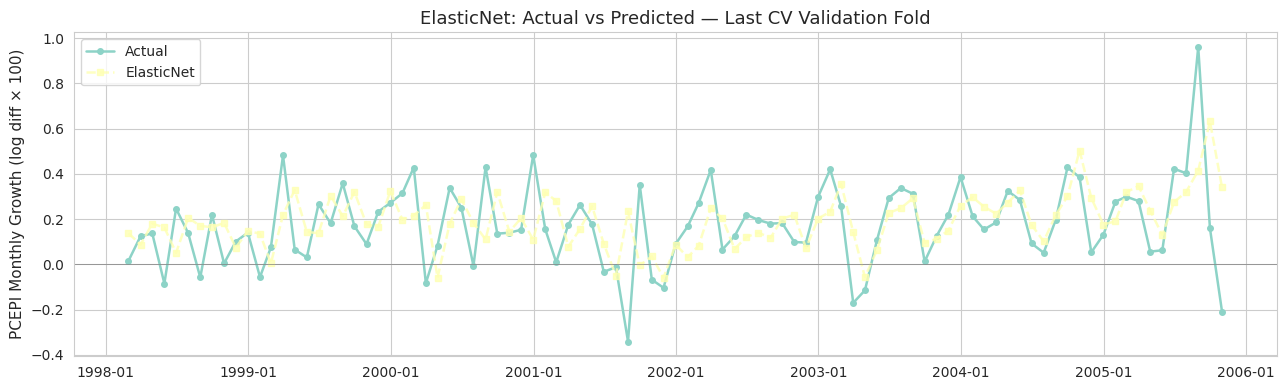

In [5]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Train ElasticNet with TimeSeriesSplit CV ---
elasticnet = InflationForecaster(model_type='elasticnet', random_state=42)
elasticnet.train(X_train, y_train, tune_hyperparameters=True, cv_folds=5)

# --- Cross-validation fold performance ---
tscv = TimeSeriesSplit(n_splits=5)
fold_metrics = []

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet

best_alpha    = elasticnet.best_params.get('alpha', 0.1)
best_l1_ratio = elasticnet.best_params.get('l1_ratio', 0.5)
X_arr = X_train.values
y_arr = y_train.values

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_arr)):
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_arr[tr_idx])
    Xval = scaler.transform(X_arr[val_idx])
    ytr, yval = y_arr[tr_idx], y_arr[val_idx]

    m = ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio, max_iter=10000, random_state=42)
    m.fit(Xtr, ytr)
    pred = m.predict(Xval)

    fold_metrics.append({
        'fold': fold + 1,
        'n_val': len(yval),
        'rmse': np.sqrt(mean_squared_error(yval, pred)),
        'mae':  mean_absolute_error(yval, pred),
        'r2':   r2_score(yval, pred),
    })

cv_df = pd.DataFrame(fold_metrics)
print("TimeSeriesSplit CV results (ElasticNet, best params):")
print(cv_df.to_string(index=False))
print(f"\nMean CV RMSE: {cv_df['rmse'].mean():.4f}  |  Mean R²: {cv_df['r2'].mean():.4f}")
print(f"Best hyperparams: {elasticnet.best_params}")

# --- Validation fold plot (last fold) ---
last_fold = list(tscv.split(X_arr))[-1]
tr_idx, val_idx = last_fold
scaler_last = StandardScaler()
Xtr_last = scaler_last.fit_transform(X_arr[tr_idx])
Xval_last = scaler_last.transform(X_arr[val_idx])
m_last = ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio, max_iter=10000, random_state=42)
m_last.fit(Xtr_last, y_arr[tr_idx])
val_pred_last = m_last.predict(Xval_last)
val_dates = X_train.index[val_idx]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(val_dates, y_arr[val_idx], 'o-', label='Actual', linewidth=1.8, markersize=4)
ax.plot(val_dates, val_pred_last, 's--', label='ElasticNet', linewidth=1.8, alpha=0.8, markersize=4)
ax.axhline(0, color='grey', linewidth=0.5)
ax.set_title('ElasticNet: Actual vs Predicted — Last CV Validation Fold')
ax.set_ylabel('PCEPI Monthly Growth (log diff × 100)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.tight_layout()
plt.show()

## Cell 6 — Compare All Models


Training set: 449 samples
Test set: 113 samples

Training ELASTICNET model...
Tuning hyperparameters for elasticnet...
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best parameters: {'alpha': 0.01, 'l1_ratio': 0.1}
Best CV score (RMSE): 0.1861

Test Set Performance:
  RMSE: 0.1707
  MAE:  0.1273
  R²:   -0.0016
  MAPE: 232.41%

Training RIDGE model...
Tuning hyperparameters for ridge...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters: {'alpha': 10.0}
Best CV score (RMSE): 0.1926

Test Set Performance:
  RMSE: 0.1790
  MAE:  0.1341
  R²:   -0.1017
  MAPE: 239.39%

Training LASSO model...
Tuning hyperparameters for lasso...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best parameters: {'alpha': 0.001}
Best CV score (RMSE): 0.1881

Test Set Performance:
  RMSE: 0.1708
  MAE:  0.1276
  R²:   -0.0025
  MAPE: 232.70%

Training RANDOM_FOREST model...
Tuning hyperparameters for random_forest...
Fitting 3 folds for each of 36 candidates

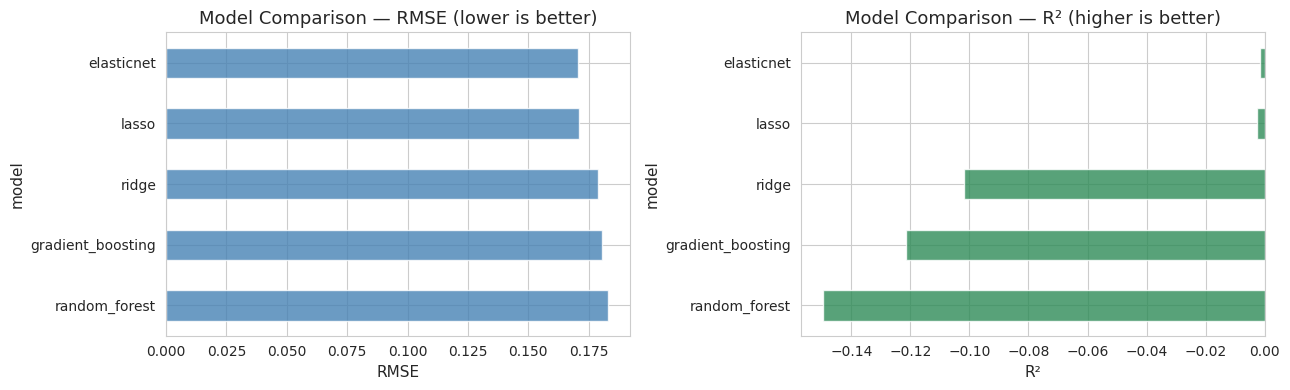


Best model by RMSE: elasticnet


In [6]:
# compare_models does an internal 80/20 temporal split on the training data
results_df, predictions_cmp, X_val_cmp, y_val_cmp = compare_models(
    X_train, y_train, test_size=0.2, random_state=42
)

print("\nModel Comparison (internal validation split of training data):")
print(results_df[['model', 'rmse', 'mae', 'r2', 'mape']].to_string(index=False))

# Bar chart of RMSE
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
results_df.plot(x='model', y='rmse', kind='barh', ax=axes[0], color='steelblue', alpha=0.8, legend=False)
axes[0].set_xlabel('RMSE')
axes[0].set_title('Model Comparison — RMSE (lower is better)')
axes[0].invert_yaxis()

results_df.plot(x='model', y='r2', kind='barh', ax=axes[1], color='seagreen', alpha=0.8, legend=False)
axes[1].set_xlabel('R²')
axes[1].set_title('Model Comparison — R² (higher is better)')
axes[1].invert_yaxis()

fig.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]['model']
print(f"\nBest model by RMSE: {best_model_name}")

## Cell 7 — Out-of-Sample Test (Feb 2026 Data)

Out-of-Sample Test Performance (ElasticNet, held-out 15%):
  Test date range: 2015-11-30 to 2025-11-30
  n observations : 121
  RMSE : 0.3407
  MAE  : 0.1703
  R²   : -1.8933
  MAPE : 208.55%


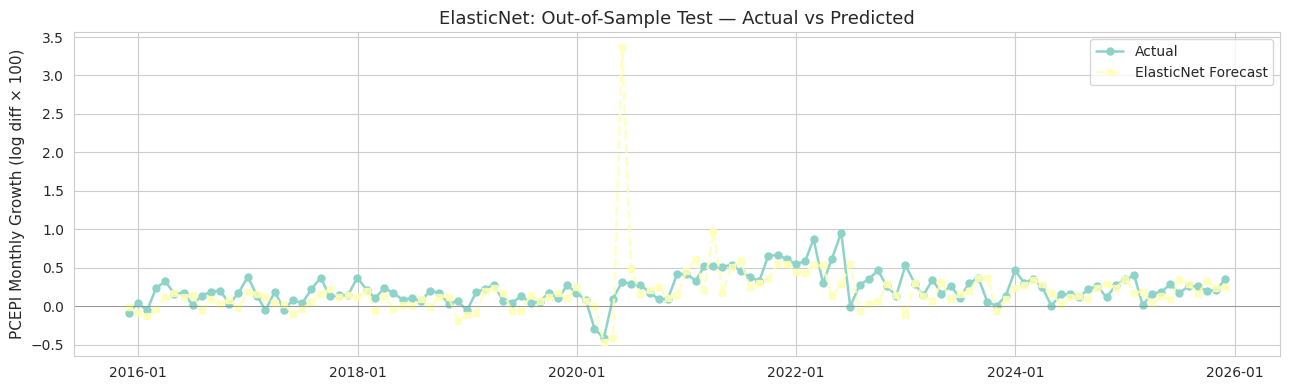

In [7]:
if len(X_test) == 0:
    print("WARNING: No out-of-sample test observations available.")
else:
    # Align test features to training feature set
    test_cols = [c for c in feature_names if c in X_test.columns]
    X_test_aligned = X_test[test_cols]

    test_metrics, y_test_pred = elasticnet.evaluate(X_test_aligned, y_test)

    print(f"Out-of-Sample Test Performance (ElasticNet, held-out 15%):")
    print(f"  Test date range: {X_test.index.min().date()} to {X_test.index.max().date()}")
    print(f"  n observations : {len(X_test)}")
    print(f"  RMSE : {test_metrics['rmse']:.4f}")
    print(f"  MAE  : {test_metrics['mae']:.4f}")
    print(f"  R²   : {test_metrics['r2']:.4f}")
    print(f"  MAPE : {test_metrics['mape']:.2f}%")

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(y_test.index, y_test.values, 'o-', label='Actual', linewidth=1.8, markersize=5)
    ax.plot(y_test.index, y_test_pred, 's--', label='ElasticNet Forecast', linewidth=1.8, alpha=0.8, markersize=5)
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.set_title('ElasticNet: Out-of-Sample Test — Actual vs Predicted')
    ax.set_ylabel('PCEPI Monthly Growth (log diff × 100)')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.tight_layout()
    plt.show()

## Cell 8 — Feature Importance

Top 15 features by |ElasticNet coefficient|:
        feature  importance
      OILPRICEx    0.033645
  TWEXAFEGSMTHx    0.030741
         AWHMAN    0.029025
       TB3SMFFM    0.027542
     WPSFD49207    0.027523
         AAAFFM    0.026219
    CUSR0000SAD    0.026139
DSERRG3M086SBEA    0.023583
        EXSZUSx    0.023404
        WPSID62    0.018304
        HOUSTMW    0.017073
       USWTRADE    0.016993
          PCEPI    0.016568
  CUSR0000SA0L5    0.015406
     WPSFD49502    0.015240

Non-zero coefficients: 60 / 126
(ElasticNet sparsity: L1 penalty drives many to exactly zero)


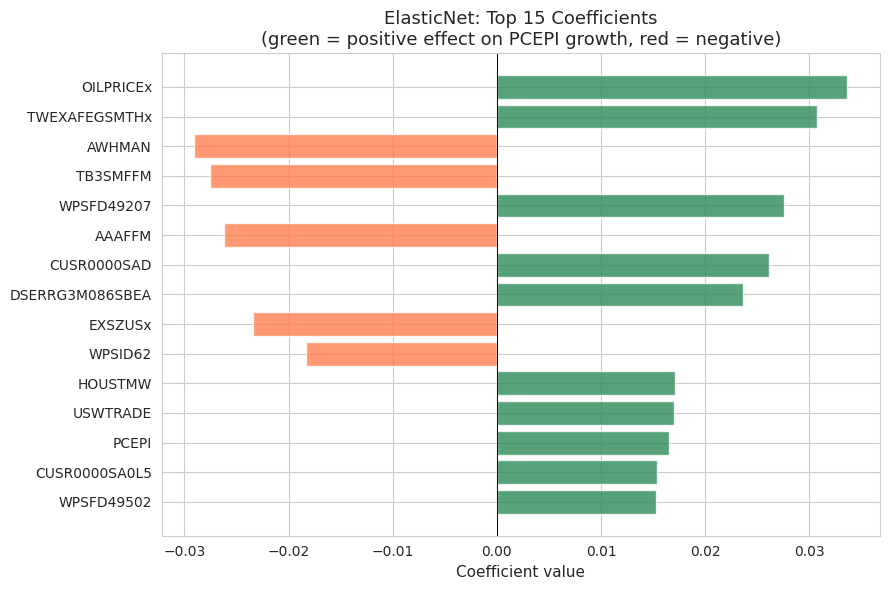

In [8]:
importance_df = elasticnet.get_feature_importance(feature_names)

if importance_df is not None:
    top15 = importance_df.head(15)
    print("Top 15 features by |ElasticNet coefficient|:")
    print(top15.to_string(index=False))

    # Also show signed coefficients for direction
    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': elasticnet.model.coef_
    }).sort_values('coefficient', key=abs, ascending=False)

    non_zero = (coef_df['coefficient'] != 0).sum()
    print(f"\nNon-zero coefficients: {non_zero} / {len(feature_names)}")
    print("(ElasticNet sparsity: L1 penalty drives many to exactly zero)")

    fig, ax = plt.subplots(figsize=(9, 6))
    colors = ['steelblue' if c >= 0 else 'coral' for c in top15['importance'].values]
    # Use signed coef for the top-15 selected by |coef|
    signed_top15 = coef_df.head(15)
    bar_colors = ['seagreen' if c >= 0 else 'coral' for c in signed_top15['coefficient']]
    ax.barh(signed_top15['feature'], signed_top15['coefficient'], color=bar_colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.7)
    ax.set_xlabel('Coefficient value')
    ax.set_title('ElasticNet: Top 15 Coefficients\n(green = positive effect on PCEPI growth, red = negative)')
    ax.invert_yaxis()
    fig.tight_layout()
    plt.show()

## Cell 9 — Residual Analysis

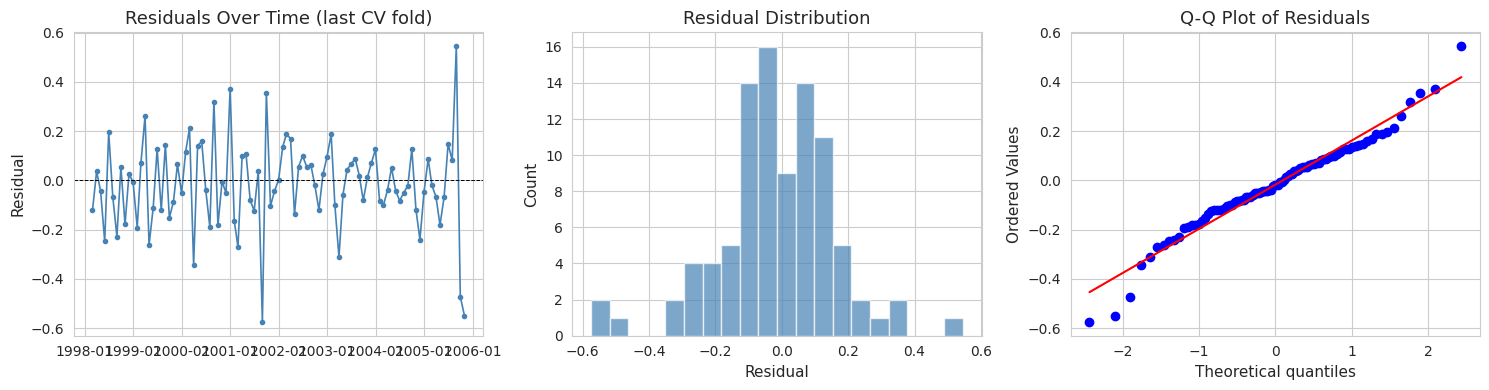

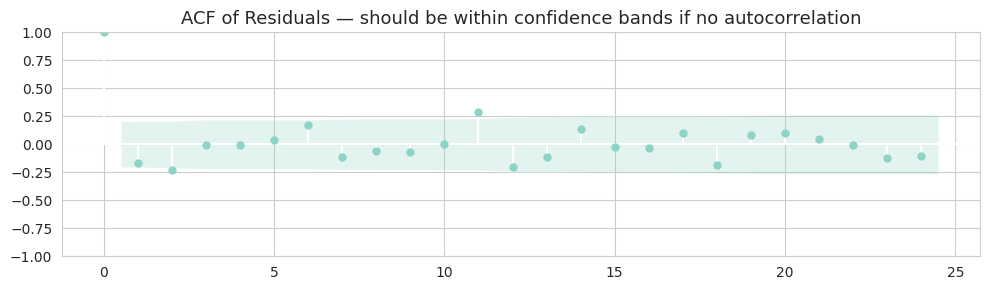

Ljung-Box test for residual autocorrelation:
      lb_stat  lb_pvalue
5    7.927628   0.160270
10  13.044127   0.221215
(p > 0.05 means no significant autocorrelation at that lag)


In [9]:
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats

# Use last-fold validation residuals for residual analysis
residuals = y_arr[val_idx] - val_pred_last

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals over time
axes[0].plot(val_dates, residuals, 'o-', linewidth=1.2, markersize=3, color='steelblue')
axes[0].axhline(0, color='black', linewidth=0.7, linestyle='--')
axes[0].set_title('Residuals Over Time (last CV fold)')
axes[0].set_ylabel('Residual')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Residual distribution
axes[1].hist(residuals, bins=20, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')

# Q-Q plot
stats.probplot(residuals, plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals')

fig.tight_layout()
plt.show()

# ACF plot of residuals
fig2, ax2 = plt.subplots(figsize=(10, 3))
plot_acf(residuals, lags=min(24, len(residuals) // 2 - 1), ax=ax2, alpha=0.05)
ax2.set_title('ACF of Residuals — should be within confidence bands if no autocorrelation')
fig2.tight_layout()
plt.show()

# Ljung-Box test for autocorrelation
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_result = acorr_ljungbox(residuals, lags=[5, 10], return_df=True)
print("Ljung-Box test for residual autocorrelation:")
print(lb_result)
print("(p > 0.05 means no significant autocorrelation at that lag)")

## Cell 10 — Conclusion

In [10]:
print("=" * 65)
print("INFLATION FORECASTING — SUMMARY")
print("=" * 65)

print(f"\nData pipeline:")
print(f"  Training vintage : {str(train_file)}")
print(f"  Target           : PCEPI (FRED API, log 1st diff x100), 1-month-ahead")
print(f"  Training samples : {len(X_train)}")
print(f"  Val samples      : {len(X_val)}")
print(f"  Test samples     : {len(X_test)}")
print(f"  Features used    : {len(feature_names)}")

print(f"\nElasticNet CV (5-fold TimeSeriesSplit):")
print(f"  Best params      : {elasticnet.best_params}")
print(f"  Mean RMSE        : {cv_df['rmse'].mean():.4f}")
print(f"  Mean R²          : {cv_df['r2'].mean():.4f}")

print(f"\nModel comparison (internal 80/20 temporal split):")
print(results_df[['model', 'rmse', 'r2']].to_string(index=False))

if len(X_test) > 0:
    print(f"\nOut-of-sample test:")
    print(f"  RMSE : {test_metrics['rmse']:.4f}")
    print(f"  R²   : {test_metrics['r2']:.4f}")

print("\nKey design choices:")
print("  - FRED-MD transformation codes applied before modeling")
print("  - All series stationary after transforms (log diffs, etc.)")
print("  - h=1 lag: features at t predict PCEPI growth at t+1")
print("  - StandardScaler inside InflationForecaster")

INFLATION FORECASTING — SUMMARY

Data pipeline:
  Training vintage : data/2026-02-MD.csv
  Target           : PCEPI (FRED API, log 1st diff x100), 1-month-ahead
  Training samples : 562
  Val samples      : 120
  Test samples     : 121
  Features used    : 126

ElasticNet CV (5-fold TimeSeriesSplit):
  Best params      : {'alpha': 0.01, 'l1_ratio': 0.3}
  Mean RMSE        : 0.2058
  Mean R²          : -0.2177

Model comparison (internal 80/20 temporal split):
            model     rmse        r2
       elasticnet 0.170716 -0.001632
            lasso 0.170791 -0.002516
            ridge 0.179043 -0.101734
gradient_boosting 0.180653 -0.121642
    random_forest 0.182892 -0.149612

Out-of-sample test:
  RMSE : 0.3407
  R²   : -1.8933

Key design choices:
  - FRED-MD transformation codes applied before modeling
  - All series stationary after transforms (log diffs, etc.)
  - h=1 lag: features at t predict PCEPI growth at t+1
  - StandardScaler inside InflationForecaster
